# 🔍 Data Quality & Consistency Checks
## Retail Analytics - DuckDB Data Validation

Este notebook realiza pruebas de consistencia y calidad de datos sobre la base de datos DuckDB del proyecto de análisis retail.

### Capas a validar:
- **Bronze**: Datos crudos
- **Silver**: Datos limpios y transformados
- **Gold**: Métricas de negocio (RFM)

---

In [3]:
# Importar librerías necesarias
import duckdb
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración de pandas para mejor visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [5]:
# Conectar a DuckDB
import os
DB_PATH = os.path.abspath('../dwh/retail_analytics.duckdb')

# Usar conexión en memoria y adjuntar la base de datos
conn = duckdb.connect(':memory:')
conn.execute(f"ATTACH '{DB_PATH}' AS retail (READ_ONLY)")

print(f"✅ Conectado a: {DB_PATH}")
print(f"📅 Fecha de análisis: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Conectado a: d:\github_projects\bi-supermarket-data\dwh\retail_analytics.duckdb
📅 Fecha de análisis: 2025-12-14 20:35:12


---
## 📊 1. Inventario de Tablas y Esquemas

Primero verificamos qué tablas existen en la base de datos.

In [6]:
# Listar todos los esquemas y tablas
query_schemas = """
SELECT 
    table_schema,
    table_name,
    table_type
FROM information_schema.tables
WHERE table_schema NOT IN ('information_schema', 'pg_catalog')
ORDER BY table_schema, table_name;
"""

df_schemas = conn.execute(query_schemas).df()
print(f"\n📋 Total de tablas encontradas: {len(df_schemas)}\n")
df_schemas


📋 Total de tablas encontradas: 1



,table_schema,table_name,table_type
0,bronze,raw_data,BASE TABLE


---
## 🥉 2. Validación Capa BRONZE

### 2.1 Conteo de Registros y Estructura

In [8]:
# Verificar tabla bronze
query_bronze_count = """
SELECT 
    COUNT(*) as total_records,
    COUNT(DISTINCT "InvoiceNo") as unique_invoices,
    COUNT(DISTINCT "CustomerID") as unique_customers,
    COUNT(DISTINCT "StockCode") as unique_products,
    COUNT(DISTINCT "Country") as unique_countries,
    MIN("InvoiceDate") as min_date,
    MAX("InvoiceDate") as max_date
FROM retail.bronze.raw_data;
"""

df_bronze_summary = conn.execute(query_bronze_count).df()
print("\n📦 BRONZE - Resumen de Datos Crudos:\n")
df_bronze_summary


📦 BRONZE - Resumen de Datos Crudos:



,total_records,unique_invoices,unique_customers,unique_products,unique_countries,min_date,max_date
0,541909,25900,4372,4070,38,1/10/2011 10:04,9/9/2011 9:52


### 2.2 Detección de Valores Nulos

In [9]:
# Análisis de nulos en Bronze
query_bronze_nulls = """
SELECT 
    COUNT(*) as total_records,
    SUM(CASE WHEN "InvoiceNo" IS NULL THEN 1 ELSE 0 END) as null_invoice_no,
    SUM(CASE WHEN "StockCode" IS NULL THEN 1 ELSE 0 END) as null_stock_code,
    SUM(CASE WHEN "Description" IS NULL THEN 1 ELSE 0 END) as null_description,
    SUM(CASE WHEN "Quantity" IS NULL THEN 1 ELSE 0 END) as null_quantity,
    SUM(CASE WHEN "InvoiceDate" IS NULL THEN 1 ELSE 0 END) as null_invoice_date,
    SUM(CASE WHEN "UnitPrice" IS NULL THEN 1 ELSE 0 END) as null_unit_price,
    SUM(CASE WHEN "CustomerID" IS NULL THEN 1 ELSE 0 END) as null_customer_id,
    SUM(CASE WHEN "Country" IS NULL THEN 1 ELSE 0 END) as null_country,
    ROUND(100.0 * SUM(CASE WHEN "CustomerID" IS NULL THEN 1 ELSE 0 END) / COUNT(*), 2) as pct_null_customer_id
FROM retail.bronze.raw_data;
"""

df_bronze_nulls = conn.execute(query_bronze_nulls).df()
print("\n🔍 BRONZE - Análisis de Valores Nulos:\n")
df_bronze_nulls


🔍 BRONZE - Análisis de Valores Nulos:



,total_records,null_invoice_no,null_stock_code,null_description,null_quantity,null_invoice_date,null_unit_price,null_customer_id,null_country,pct_null_customer_id
0,541909,0.00,0.00,1454.00,0.00,0.00,0.00,135080.00,0.00,24.93


### 2.3 Detección de Valores Anómalos

In [10]:
# Análisis de valores anómalos en Bronze
query_bronze_anomalies = """
SELECT 
    COUNT(*) as total_records,
    SUM(CASE WHEN "Quantity" <= 0 THEN 1 ELSE 0 END) as negative_or_zero_quantity,
    SUM(CASE WHEN "UnitPrice" <= 0 THEN 1 ELSE 0 END) as negative_or_zero_price,
    SUM(CASE WHEN "InvoiceNo" LIKE 'C%' THEN 1 ELSE 0 END) as cancelled_transactions,
    ROUND(100.0 * SUM(CASE WHEN "Quantity" <= 0 THEN 1 ELSE 0 END) / COUNT(*), 2) as pct_invalid_quantity,
    ROUND(100.0 * SUM(CASE WHEN "UnitPrice" <= 0 THEN 1 ELSE 0 END) / COUNT(*), 2) as pct_invalid_price,
    ROUND(100.0 * SUM(CASE WHEN "InvoiceNo" LIKE 'C%' THEN 1 ELSE 0 END) / COUNT(*), 2) as pct_cancelled
FROM retail.bronze.raw_data;
"""

df_bronze_anomalies = conn.execute(query_bronze_anomalies).df()
print("\n⚠️ BRONZE - Detección de Anomalías:\n")
df_bronze_anomalies


⚠️ BRONZE - Detección de Anomalías:



,total_records,negative_or_zero_quantity,negative_or_zero_price,cancelled_transactions,pct_invalid_quantity,pct_invalid_price,pct_cancelled
0,541909,10624.00,2517.00,9288.00,1.96,0.46,1.71


### 2.4 Distribución de Países

In [11]:
# Top 10 países por volumen de transacciones
query_bronze_countries = """
SELECT 
    "Country",
    COUNT(*) as num_transactions,
    COUNT(DISTINCT "CustomerID") as num_customers,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) as pct_transactions
FROM retail.bronze.raw_data
WHERE "Country" IS NOT NULL
GROUP BY "Country"
ORDER BY num_transactions DESC
LIMIT 10;
"""

df_bronze_countries = conn.execute(query_bronze_countries).df()
print("\n🌍 BRONZE - Top 10 Países por Transacciones:\n")
df_bronze_countries


🌍 BRONZE - Top 10 Países por Transacciones:



,Country,num_transactions,num_customers,pct_transactions
0,United Kingdom,495478,3950,91.43
1,Germany,9495,95,1.75
2,France,8557,87,1.58
3,EIRE,8196,3,1.51
4,Spain,2533,31,0.47
5,Netherlands,2371,9,0.44
6,Belgium,2069,25,0.38
7,Switzerland,2002,21,0.37
8,Portugal,1519,19,0.28
9,Australia,1259,9,0.23


In [18]:
# Tabla de productos: stock_code y description
query_products = """
SELECT DISTINCT
    StockCode,
    description
FROM retail.bronze.raw_data
ORDER BY StockCode;
"""

df_products = conn.execute(query_products).df()
print(f"\n📦 Total de productos únicos: {len(df_products)}\n")
df_products


📦 Total de productos únicos: 5752



,StockCode,Description
0,10002,None
1,10002,INFLATABLE POLITICAL GLOBE
2,10080,None
3,10080,GROOVY CACTUS INFLATABLE
4,10080,check
...,...,...
5747,gift_0001_30,None
5748,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00
5749,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00
5750,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00


In [26]:
# 📦 EDA: Análisis de inconsistencias en descriptions (CAPA BRONZE)
query_bronze_product_variations = """
SELECT 
    "StockCode",
    "Description",
    COUNT(*) as num_transactions
FROM retail.bronze.raw_data
WHERE "StockCode" IS NOT NULL
GROUP BY "StockCode", "Description"
ORDER BY "StockCode", num_transactions DESC;
"""

df_bronze_products = conn.execute(query_bronze_product_variations).df()
print(f"\n📦 Total de combinaciones StockCode + Description en Bronze: {len(df_bronze_products)}\n")
df_bronze_products.head(30)


📦 Total de combinaciones StockCode + Description en Bronze: 5752



,StockCode,Description,num_transactions
0,10002,INFLATABLE POLITICAL GLOBE,71
1,10002,None,2
2,10080,GROOVY CACTUS INFLATABLE,22
3,10080,check,1
4,10080,None,1
5,10120,DOGGY RUBBER,30
6,10123C,HEARTS WRAPPING TAPE,3
7,10123C,None,1
8,10123G,None,1
9,10124A,SPOTS ON RED BOOKCOVER TAPE,5


In [29]:
# 🔍 Identificar StockCodes con múltiples descripciones (BRONZE)
query_bronze_inconsistent = """
WITH product_variations AS (
    SELECT 
        "StockCode",
        COUNT(DISTINCT "Description") as num_different_descriptions,
        STRING_AGG(DISTINCT "Description", ' | ') as all_descriptions
    FROM retail.bronze.raw_data
    WHERE "StockCode" IS NOT NULL
    GROUP BY "StockCode"
)
SELECT 
    "StockCode",
    num_different_descriptions,
    all_descriptions
FROM product_variations
WHERE num_different_descriptions > 1
ORDER BY num_different_descriptions DESC
;
"""

df_bronze_inconsistent = conn.execute(query_bronze_inconsistent).df()
print(f"\n⚠️ Stock codes con múltiples descripciones en Bronze: {len(df_bronze_inconsistent)}\n")
df_bronze_inconsistent


⚠️ Stock codes con múltiples descripciones en Bronze: 650



,StockCode,num_different_descriptions,all_descriptions
0,20713,8,wrongly coded-23343 | wrongly marked 23343 | w...
1,23084,7,Amazon | RABBIT NIGHT LIGHT | temp adjustment ...
2,21830,6,? | damaged | ASSORTED CREEPY CRAWLIES | OOPS ...
3,85175,6,Amazon sold sets | dotcom sold sets | ? sold a...
4,23343,5,20713 wrongly marked | came coded as 20713 | 2...
...,...,...,...
645,23251,2,ENAMEL MUG PANTRY | VINTAGE RED ENAMEL TRIM MUG
646,23114,2,VINTAGE LEAF CHOPPING BOARD | Damaged
647,23157,2,check | SET OF 6 NATIVITY MAGNETS
648,84507C,2,BLUE CIRCLES DESIGN MONKEY DOLL | adjustment


In [30]:
# 📊 Estadísticas del problema de calidad de datos
total_stock_codes = conn.execute('SELECT COUNT(DISTINCT "StockCode") FROM retail.bronze.raw_data WHERE "StockCode" IS NOT NULL').fetchone()[0]
stock_codes_with_issues = len(df_bronze_inconsistent)
pct_with_issues = round(100.0 * stock_codes_with_issues / total_stock_codes, 2)

print(f"""
📋 RESUMEN DEL PROBLEMA DE CALIDAD:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total de StockCodes únicos: {total_stock_codes}
StockCodes con múltiples descripciones: {stock_codes_with_issues}
Porcentaje afectado: {pct_with_issues}%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

💡 RECOMENDACIÓN: 
Este problema debe resolverse en la transformación a Silver mediante:
1. Selección de descripción canónica (más frecuente)
2. Exclusión de valores inválidos (NULL, 'check', 'test', etc.)
3. Creación de tabla de referencia product_master
""")


📋 RESUMEN DEL PROBLEMA DE CALIDAD:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total de StockCodes únicos: 4070
StockCodes con múltiples descripciones: 650
Porcentaje afectado: 15.97%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

💡 RECOMENDACIÓN: 
Este problema debe resolverse en la transformación a Silver mediante:
1. Selección de descripción canónica (más frecuente)
2. Exclusión de valores inválidos (NULL, 'check', 'test', etc.)
3. Creación de tabla de referencia product_master



In [31]:
# Ver los 10 StockCodes con más variaciones de descripción
query_worst_cases = """
WITH product_variations AS (
    SELECT 
        "StockCode",
        COUNT(DISTINCT "Description") as num_variations,
        STRING_AGG(DISTINCT "Description", ' | ' ORDER BY "Description") as all_descriptions
    FROM retail.bronze.raw_data
    WHERE "StockCode" IS NOT NULL
    GROUP BY "StockCode"
)
SELECT 
    "StockCode",
    num_variations,
    all_descriptions
FROM product_variations
WHERE num_variations > 1
ORDER BY num_variations DESC
LIMIT 10;
"""

df_worst_cases = conn.execute(query_worst_cases).df()
print("\n🔴 Top 10 StockCodes con más variaciones:\n")
df_worst_cases


🔴 Top 10 StockCodes con más variaciones:



,StockCode,num_variations,all_descriptions
0,20713,8,Found | JUMBO BAG OWLS | Marked as 23343 | fou...
1,23084,7,Amazon | RABBIT NIGHT LIGHT | add stock to all...
2,21830,6,? | ASSORTED CREEPY CRAWLIES | MERCHANT CHANDL...
3,85175,6,? sold as sets? | Amazon sold sets | CACTI T-L...
4,21181,5,PLEASE ONE PERSON METAL SIGN | adjustment | ch...
5,85172,5,?sold as sets? | Dotcom set | HYACINTH BULB T-...
6,23131,5,? | MISELTOE HEART WREATH CREAM | MISELTOE HEA...
7,72807A,5,???missing | AMAZON | SET/3 ROSE CANDLE IN JEW...
8,23343,5,20713 | 20713 wrongly marked | JUMBO BAG VINTA...
9,37327,4,ASSTD MULTICOLOUR CIRCLES MUG | adjustment | d...


In [32]:
# ¿Cuántas transacciones están afectadas por este problema?
query_impact = """
WITH problematic_stocks AS (
    SELECT DISTINCT "StockCode"
    FROM (
        SELECT 
            "StockCode",
            COUNT(DISTINCT "Description") as num_desc
        FROM retail.bronze.raw_data
        WHERE "StockCode" IS NOT NULL
        GROUP BY "StockCode"
        HAVING COUNT(DISTINCT "Description") > 1
    )
)
SELECT 
    COUNT(*) as affected_transactions,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM retail.bronze.raw_data), 2) as pct_affected
FROM retail.bronze.raw_data
WHERE "StockCode" IN (SELECT "StockCode" FROM problematic_stocks);
"""

df_impact = conn.execute(query_impact).df()
print("\n📊 Impacto en transacciones:\n")
df_impact


📊 Impacto en transacciones:



,affected_transactions,pct_affected
0,113465,20.94


In [33]:
# Contar cuántos tienen NULL, 'check', u otros valores sospechosos
query_patterns = """
SELECT 
    CASE 
        WHEN "Description" IS NULL THEN 'NULL'
        WHEN LOWER("Description") IN ('check', 'test', 'manual', '?', '') THEN 'Invalid/Generic'
        ELSE 'Valid'
    END as description_type,
    COUNT(*) as num_records,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM retail.bronze.raw_data), 2) as pct_total
FROM retail.bronze.raw_data
GROUP BY description_type
ORDER BY num_records DESC;
"""

df_patterns = conn.execute(query_patterns).df()
print("\n🔍 Patrones de descripciones:\n")
df_patterns


🔍 Patrones de descripciones:



,description_type,num_records,pct_total
0,Valid,539671,99.59
1,NULL,1454,0.27
2,Invalid/Generic,784,0.14


In [34]:
# Analizar en detalle un StockCode problemático
def analyze_product_detail(stock_code):
    query = f"""
    SELECT 
        "StockCode",
        "Description",
        COUNT(*) as num_transactions,
        SUM("Quantity") as total_quantity,
        ROUND(SUM("Quantity" * "UnitPrice"), 2) as total_revenue,
        MIN("InvoiceDate") as first_seen,
        MAX("InvoiceDate") as last_seen
    FROM retail.bronze.raw_data
    WHERE "StockCode" = '{stock_code}'
    GROUP BY "StockCode", "Description"
    ORDER BY num_transactions DESC;
    """
    return conn.execute(query).df()

# Analizar el caso más problemático
print("🔍 Análisis detallado de StockCode '20713':\n")
analyze_product_detail('20713')

🔍 Análisis detallado de StockCode '20713':



,StockCode,Description,num_transactions,total_quantity,total_revenue,first_seen,last_seen
0,20713,JUMBO BAG OWLS,673,11201.00,22599.53,1/10/2011 12:36,9/9/2011 15:51
1,20713,None,4,58.00,0.00,3/28/2011 15:16,3/29/2011 17:11
2,20713,Found,1,100.00,0.00,10/24/2011 10:53,10/24/2011 10:53
3,20713,Marked as 23343,1,400.00,0.00,10/26/2011 14:14,10/26/2011 14:14
4,20713,wrongly coded-23343,1,-800.00,0.00,10/6/2011 12:38,10/6/2011 12:38
5,20713,wrongly marked 23343,1,200.00,0.00,10/24/2011 17:01,10/24/2011 17:01
6,20713,wrongly coded 23343,1,1000.00,0.00,10/27/2011 15:36,10/27/2011 15:36
7,20713,wrongly marked. 23343 in box,1,-3100.00,0.00,7/14/2011 14:27,7/14/2011 14:27
8,20713,found,1,100.00,0.00,10/18/2011 11:27,10/18/2011 11:27


In [36]:
# Identificar descripciones "válidas" vs "notas operativas"
query_description_classification = """
SELECT 
    "StockCode",
    "Description",
    COUNT(*) as frequency,
    CASE 
        WHEN "Description" IS NULL THEN 'NULL'
        WHEN "Description" ~ '^[?]+' THEN 'Starts with ?'
        WHEN LOWER("Description") IN ('check', 'test', 'manual', 'found', 'adjustment', 'amazon') THEN 'Operational Note'
        WHEN "Description" ~ 'marked|wrongly|missing|add stock|sold as' THEN 'Inventory Note'
        WHEN LENGTH("Description") < 3 THEN 'Too Short'
        ELSE 'Valid Product Name'
    END as classification
FROM retail.bronze.raw_data
WHERE "StockCode" IN (
    SELECT "StockCode" 
    FROM retail.bronze.raw_data 
    WHERE "StockCode" IS NOT NULL
    GROUP BY "StockCode"
    HAVING COUNT(DISTINCT "Description") > 1
)
GROUP BY "StockCode", "Description", classification
ORDER BY "StockCode", frequency DESC
;
"""

df_classification = conn.execute(query_description_classification).df()
print("\n📊 Clasificación de descripciones problemáticas:\n")
df_classification.head(30)


📊 Clasificación de descripciones problemáticas:



,StockCode,Description,frequency,classification
0,10080,GROOVY CACTUS INFLATABLE,22,Valid Product Name
1,10080,None,1,NULL
2,10080,check,1,Operational Note
3,10133,COLOURING PENCILS BROWN TUBE,199,Valid Product Name
4,10133,damaged,1,Valid Product Name
5,15058A,BLUE POLKADOT GARDEN PARASOL,93,Valid Product Name
6,15058A,None,1,NULL
7,15058A,wet/rusty,1,Valid Product Name
8,15058C,ICE CREAM DESIGN GARDEN PARASOL,72,Valid Product Name
9,15058C,wet/rusty,1,Valid Product Name


In [37]:
# Análisis de tipos de transacciones
query_transaction_types = """
SELECT 
    CASE 
        WHEN "InvoiceNo" LIKE 'C%' THEN 'Cancelación/Devolución'
        ELSE 'Venta Normal'
    END as transaction_type,
    CASE 
        WHEN "Quantity" < 0 THEN 'Cantidad Negativa'
        WHEN "Quantity" = 0 THEN 'Cantidad Cero'
        ELSE 'Cantidad Positiva'
    END as quantity_type,
    COUNT(*) as num_records,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM retail.bronze.raw_data), 2) as pct_total
FROM retail.bronze.raw_data
GROUP BY transaction_type, quantity_type
ORDER BY num_records DESC;
"""

df_transaction_types = conn.execute(query_transaction_types).df()
print("\n📊 Tipos de Transacciones:\n")
df_transaction_types


📊 Tipos de Transacciones:



,transaction_type,quantity_type,num_records,pct_total
0,Venta Normal,Cantidad Positiva,531285,98.04
1,Cancelación/Devolución,Cantidad Negativa,9288,1.71
2,Venta Normal,Cantidad Negativa,1336,0.25


In [38]:
# Ver ejemplos de registros inconsistentes (Venta Normal con Cantidad Negativa)
query_inconsistent_transactions = """
SELECT 
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "UnitPrice",
    "InvoiceDate",
    "CustomerID",
    "Country"
FROM retail.bronze.raw_data
WHERE "InvoiceNo" NOT LIKE 'C%'  -- No es cancelación
  AND "Quantity" < 0              -- Pero tiene cantidad negativa
ORDER BY "Quantity" ASC
LIMIT 20;
"""

df_inconsistent = conn.execute(query_inconsistent_transactions).df()
print("\n⚠️ Registros Inconsistentes (Venta Normal con Cantidad Negativa):\n")
df_inconsistent


⚠️ Registros Inconsistentes (Venta Normal con Cantidad Negativa):



,InvoiceNo,StockCode,Description,Quantity,UnitPrice,InvoiceDate,CustomerID,Country
0,556690,23005,printing smudges/thrown away,-9600,0.00,6/14/2011 10:37,None,United Kingdom
1,556691,23005,printing smudges/thrown away,-9600,0.00,6/14/2011 10:37,None,United Kingdom
2,556687,23003,Printing smudges/thrown away,-9058,0.00,6/14/2011 10:36,None,United Kingdom
3,546152,72140F,throw away,-5368,0.00,3/9/2011 17:25,None,United Kingdom
4,573596,79323W,"Unsaleable, destroyed.",-4830,0.00,10/31/2011 15:17,None,United Kingdom
5,566768,16045,None,-3667,0.00,9/14/2011 17:53,None,United Kingdom
6,565304,16259,None,-3167,0.00,9/2/2011 12:18,None,United Kingdom
7,560039,20713,wrongly marked. 23343 in box,-3100,0.00,7/14/2011 14:27,None,United Kingdom
8,545990,84598,check,-3000,0.00,3/8/2011 13:07,None,United Kingdom
9,569466,23270,incorrect stock entry.,-2880,0.00,10/4/2011 11:42,None,United Kingdom


In [39]:
# ¿Hay cancelaciones (InvoiceNo con 'C') que tengan cantidad POSITIVA?
query_reverse_inconsistency = """
SELECT 
    COUNT(*) as num_records,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM retail.bronze.raw_data WHERE "InvoiceNo" LIKE 'C%'), 2) as pct_of_cancellations
FROM retail.bronze.raw_data
WHERE "InvoiceNo" LIKE 'C%'      -- Es cancelación
  AND "Quantity" > 0;             -- Pero tiene cantidad positiva
"""

df_reverse = conn.execute(query_reverse_inconsistency).df()
print("\n🔄 ¿Cancelaciones con Cantidad Positiva?:\n")
df_reverse


🔄 ¿Cancelaciones con Cantidad Positiva?:



,num_records,pct_of_cancellations
0,0,0.00


In [40]:
# Verificar si las facturas tienen múltiples líneas
query_check_invoices = """
SELECT 
    "InvoiceNo",
    COUNT(*) as num_line_items,
    SUM("Quantity") as total_quantity,
    ROUND(SUM("Quantity" * "UnitPrice"), 2) as total_amount,
    COUNT(DISTINCT "CustomerID") as num_customers,
    STRING_AGG(DISTINCT "Description", ' | ') as descriptions
FROM retail.bronze.raw_data
WHERE "InvoiceNo" IN ('556690', '556691', '556687', '546152', '573596')
GROUP BY "InvoiceNo"
ORDER BY "InvoiceNo";
"""

df_invoice_detail = conn.execute(query_check_invoices).df()
print("\n🔍 Detalle de facturas sospechosas:\n")
df_invoice_detail


🔍 Detalle de facturas sospechosas:



,InvoiceNo,num_line_items,total_quantity,total_amount,num_customers,descriptions
0,546152,1,-5368.00,0.00,0,throw away
1,556687,1,-9058.00,0.00,0,Printing smudges/thrown away
2,556690,1,-9600.00,0.00,0,printing smudges/thrown away
3,556691,1,-9600.00,0.00,0,printing smudges/thrown away
4,573596,1,-4830.00,0.00,0,"Unsaleable, destroyed."


In [41]:
# Caracterizar TODOS los registros con Quantity negativa pero sin 'C' en InvoiceNo
query_negative_analysis = """
SELECT 
    CASE 
        WHEN "UnitPrice" = 0 THEN 'Precio = 0'
        ELSE 'Precio > 0'
    END as price_category,
    CASE 
        WHEN "CustomerID" IS NULL THEN 'Sin CustomerID'
        ELSE 'Con CustomerID'
    END as customer_category,
    COUNT(*) as num_records,
    ROUND(100.0 * COUNT(*) / 1336, 2) as pct_of_inconsistent,
    STRING_AGG(DISTINCT "Description", ' | ') as sample_descriptions
FROM retail.bronze.raw_data
WHERE "InvoiceNo" NOT LIKE 'C%'
  AND "Quantity" < 0
GROUP BY price_category, customer_category
ORDER BY num_records DESC;
"""

df_negative_analysis = conn.execute(query_negative_analysis).df()
print("\n📊 Análisis de registros con Quantity negativa (sin 'C'):\n")
df_negative_analysis


📊 Análisis de registros con Quantity negativa (sin 'C'):



,price_category,customer_category,num_records,pct_of_inconsistent,sample_descriptions
0,Precio = 0,Sin CustomerID,1336,100.00,"damages | lost?? | Breakages | Unsaleable, des..."


In [44]:
# Análisis de variación de precios por StockCode
query_price_variations = """
WITH price_stats AS (
    SELECT 
        "StockCode",
        COUNT(DISTINCT "UnitPrice") as num_different_prices,
        MIN("UnitPrice") as min_price,
        MAX("UnitPrice") as max_price,
        ROUND(AVG("UnitPrice"), 2) as avg_price,
        ROUND(STDDEV("UnitPrice"), 2) as stddev_price,
        COUNT(*) as num_transactions
    FROM retail.bronze.raw_data
    WHERE "UnitPrice" > 0  -- Excluir ajustes de inventario
      AND "StockCode" IS NOT NULL
    GROUP BY "StockCode"
)
SELECT 
    "StockCode",
    num_different_prices,
    min_price,
    max_price,
    avg_price,
    stddev_price,
    num_transactions,
    ROUND(100.0 * (max_price - min_price) / NULLIF(min_price, 0), 2) as pct_variation
FROM price_stats
WHERE num_different_prices > 1  -- Solo productos con variación de precio
ORDER BY num_different_prices DESC, pct_variation DESC
LIMIT 30;
"""

df_price_variations = conn.execute(query_price_variations).df()
print(f"\n💰 Productos con múltiples precios: {len(df_price_variations)}\n")
df_price_variations


💰 Productos con múltiples precios: 30



,StockCode,num_different_prices,min_price,max_price,avg_price,stddev_price,num_transactions,pct_variation
0,DOT,686,0.35,4505.17,291.73,355.64,707,1287091.43
1,M,259,0.03,38970.00,379.55,1782.38,565,129899900.00
2,POST,113,0.55,8142.75,37.05,326.62,1252,1480400.00
3,D,75,0.01,1867.86,72.48,219.27,77,18678500.00
4,S,59,2.80,570.00,50.40,85.66,63,20257.14
5,AMAZONFEE,30,1.00,17836.46,7324.78,4619.55,34,1783546.00
6,BANK CHARGES,26,0.00,1050.15,202.86,271.79,37,105014900.00
7,CRUK,16,1.60,1100.44,495.84,364.16,16,68677.50
8,79321,15,3.82,17.88,6.77,2.87,676,368.06
9,47566,15,3.74,15.79,5.78,2.12,1726,322.19


In [46]:
# Tabla de precios por producto y país
query_price_by_product_country = """
SELECT 
    "StockCode",
    "Country",
    COUNT(DISTINCT "UnitPrice") as num_different_prices,
    MIN("UnitPrice") as min_price,
    MAX("UnitPrice") as max_price,
    ROUND(AVG("UnitPrice"), 2) as avg_price,
    MODE("UnitPrice") as most_common_price,
    COUNT(*) as num_transactions,
    MIN("InvoiceDate") as first_transaction,
    MAX("InvoiceDate") as last_transaction
FROM retail.bronze.raw_data
WHERE "UnitPrice" > 0
  AND "StockCode" IS NOT NULL
  AND "Country" IS NOT NULL
GROUP BY "StockCode", "Country"
ORDER BY "StockCode", "Country";
"""

df_price_product_country = conn.execute(query_price_by_product_country).df()
print(f"\n💰 Tabla de Precios: StockCode × Country\n")
print(f"Total de combinaciones: {len(df_price_product_country)}\n")
df_price_product_country.head(30)


💰 Tabla de Precios: StockCode × Country

Total de combinaciones: 19701



,StockCode,Country,num_different_prices,min_price,max_price,avg_price,most_common_price,num_transactions,first_transaction,last_transaction
0,10002,EIRE,1,0.85,0.85,0.85,0.85,1,12/10/2010 12:33,12/10/2010 12:33
1,10002,France,1,0.85,0.85,0.85,0.85,8,1/20/2011 10:48,4/1/2011 11:10
2,10002,Germany,1,0.85,0.85,0.85,0.85,1,1/17/2011 11:46,1/17/2011 11:46
3,10002,Japan,1,0.85,0.85,0.85,0.85,1,2/4/2011 10:31,2/4/2011 10:31
4,10002,Spain,1,0.85,0.85,0.85,0.85,1,1/18/2011 14:04,1/18/2011 14:04
5,10002,Switzerland,1,0.85,0.85,0.85,0.85,1,1/19/2011 9:05,1/19/2011 9:05
6,10002,United Kingdom,3,0.85,1.66,1.14,0.85,58,1/11/2011 10:19,4/3/2011 15:07
7,10080,United Kingdom,2,0.39,0.85,0.41,0.39,22,10/10/2011 15:39,9/8/2011 8:56
8,10120,France,1,0.21,0.21,0.21,0.21,1,11/4/2011 13:15,11/4/2011 13:15
9,10120,United Kingdom,1,0.21,0.21,0.21,0.21,29,10/23/2011 13:49,9/4/2011 11:00


In [47]:
# ¿Cuántos productos tienen precios diferentes por país?
query_price_variation_by_country = """
WITH product_country_prices AS (
    SELECT 
        "StockCode",
        "Country",
        ROUND(AVG("UnitPrice"), 2) as avg_price
    FROM retail.bronze.raw_data
    WHERE "UnitPrice" > 0
      AND "StockCode" IS NOT NULL
      AND "Country" IS NOT NULL
    GROUP BY "StockCode", "Country"
),
products_with_variations AS (
    SELECT 
        "StockCode",
        COUNT(DISTINCT avg_price) as num_different_prices_across_countries,
        MIN(avg_price) as min_price,
        MAX(avg_price) as max_price,
        COUNT(DISTINCT "Country") as num_countries
    FROM product_country_prices
    GROUP BY "StockCode"
    HAVING COUNT(DISTINCT avg_price) > 1
)
SELECT 
    "StockCode",
    num_different_prices_across_countries,
    num_countries,
    min_price,
    max_price,
    ROUND(100.0 * (max_price - min_price) / NULLIF(min_price, 0), 2) as pct_variation
FROM products_with_variations
ORDER BY pct_variation DESC
LIMIT 30;
"""

df_country_price_variations = conn.execute(query_price_variation_by_country).df()
print(f"\n🌍 Productos con precios diferentes por país: {len(df_country_price_variations)}\n")
df_country_price_variations


🌍 Productos con precios diferentes por país: 30



,StockCode,num_different_prices_across_countries,num_countries,min_price,max_price,pct_variation
0,M,16,16,0.22,1854.60,842900.00
1,POST,24,24,15.00,550.94,3572.93
2,D,4,4,26.33,434.51,1550.25
3,22390,5,7,0.39,3.56,812.82
4,16219,3,5,0.06,0.54,800.00
5,21144,2,2,0.38,3.36,784.21
6,22395,3,3,0.39,3.44,782.05
7,22393,4,6,0.39,3.12,700.00
8,22391,2,3,0.39,3.06,684.62
9,85071A,4,6,0.38,2.95,676.32


In [48]:
# Analizar en detalle los StockCodes sospechosos
def analyze_suspicious_stockcode(stock_code):
    query = f"""
    SELECT 
        "StockCode",
        "Description",
        "Country",
        "UnitPrice",
        "Quantity",
        "InvoiceNo",
        "InvoiceDate",
        "CustomerID"
    FROM retail.bronze.raw_data
    WHERE "StockCode" = '{stock_code}'
      AND "UnitPrice" > 0
    ORDER BY "UnitPrice" DESC
    LIMIT 20;
    """
    return conn.execute(query).df()

# Analizar cada caso
print("🔍 Análisis de StockCode 'M':\n")
df_m = analyze_suspicious_stockcode('M')
display(df_m)

print("\n🔍 Análisis de StockCode 'POST':\n")
df_post = analyze_suspicious_stockcode('POST')
display(df_post)

print("\n🔍 Análisis de StockCode 'D':\n")
df_d = analyze_suspicious_stockcode('D')
display(df_d)

🔍 Análisis de StockCode 'M':



,StockCode,Description,Country,UnitPrice,Quantity,InvoiceNo,InvoiceDate,CustomerID
0,M,Manual,United Kingdom,38970.00,-1,C556445,6/10/2011 15:31,15098
1,M,Manual,United Kingdom,6930.00,-1,C551699,5/3/2011 14:12,16029
2,M,Manual,United Kingdom,4287.63,-1,C560372,7/18/2011 12:26,17448
3,M,Manual,United Kingdom,4287.63,1,560373,7/18/2011 12:30,None
4,M,Manual,France,4161.06,1,573077,10/27/2011 14:13,12536
5,M,Manual,France,4161.06,-2,C573079,10/27/2011 14:15,12536
6,M,Manual,France,4161.06,1,573080,10/27/2011 14:20,12536
7,M,Manual,Singapore,3949.32,-1,C571750,10/19/2011 11:16,12744
8,M,Manual,Singapore,3949.32,1,571751,10/19/2011 11:18,12744
9,M,Manual,United Kingdom,3155.95,1,569382,10/3/2011 16:44,15502



🔍 Análisis de StockCode 'POST':



,StockCode,Description,Country,UnitPrice,Quantity,InvoiceNo,InvoiceDate,CustomerID
0,POST,POSTAGE,United Kingdom,8142.75,-1,C551685,5/3/2011 12:51,16029
1,POST,POSTAGE,United Kingdom,8142.75,1,551697,5/3/2011 13:46,16029
2,POST,POSTAGE,Norway,700.00,1,557754,6/22/2011 13:12,12432
3,POST,POSTAGE,Canada,550.94,1,560187,7/15/2011 12:05,17444
4,POST,POSTAGE,United Kingdom,545.58,-1,C557638,6/21/2011 16:01,17450
5,POST,POSTAGE,Germany,523.00,1,552980,5/12/2011 14:52,12590
6,POST,POSTAGE,Australia,350.00,1,548661,4/1/2011 14:28,12415
7,POST,POSTAGE,Italy,300.00,1,577609,11/21/2011 9:51,12349
8,POST,POSTAGE,Australia,262.73,-1,C574344,11/4/2011 10:18,12415
9,POST,POSTAGE,Germany,240.00,1,569639,10/5/2011 12:24,12471



🔍 Análisis de StockCode 'D':



,StockCode,Description,Country,UnitPrice,Quantity,InvoiceNo,InvoiceDate,CustomerID
0,D,Discount,United Kingdom,1867.86,-1,C549452,4/8/2011 14:17,17940
1,D,Discount,EIRE,434.51,-1,C563225,8/14/2011 14:35,14911
2,D,Discount,United Kingdom,281.00,-1,C537597,12/7/2010 12:34,15498
3,D,Discount,United Kingdom,267.12,-1,C537857,12/8/2010 16:00,17340
4,D,Discount,Netherlands,206.40,-1,C563593,8/18/2011 6:13,14646
5,D,Discount,United Kingdom,183.00,-1,C576218,11/14/2011 12:57,13694
6,D,Discount,United Kingdom,162.24,-1,C548411,3/31/2011 10:36,13316
7,D,Discount,United Kingdom,129.90,-1,C556877,6/15/2011 12:00,15498
8,D,Discount,United Kingdom,120.00,-1,C551190,4/27/2011 10:22,17940
9,D,Discount,United Kingdom,110.43,-1,C565390,9/2/2011 16:23,13408


In [49]:
# Identificar StockCodes anómalos
query_anomalous_stockcodes = """
SELECT 
    "StockCode",
    LENGTH("StockCode") as code_length,
    COUNT(*) as num_transactions,
    COUNT(DISTINCT "Description") as num_descriptions,
    STRING_AGG(DISTINCT "Description", ' | ') as descriptions,
    MIN("UnitPrice") as min_price,
    MAX("UnitPrice") as max_price
FROM retail.bronze.raw_data
WHERE "UnitPrice" > 0
  AND (
      LENGTH("StockCode") <= 2  -- Muy cortos
      OR "StockCode" ~ '^[A-Z]$'  -- Una sola letra
      OR "StockCode" IN ('POST', 'BANK CHARGES', 'M', 'D', 'DOT', 'PADS', 'C2')
  )
GROUP BY "StockCode"
ORDER BY num_transactions DESC;
"""

df_anomalous = conn.execute(query_anomalous_stockcodes).df()
print("\n⚠️ StockCodes Anómalos:\n")
df_anomalous


⚠️ StockCodes Anómalos:



,StockCode,code_length,num_transactions,num_descriptions,descriptions,min_price,max_price
0,POST,4,1252,1,POSTAGE,0.55,8142.75
1,DOT,3,707,1,DOTCOM POSTAGE,0.35,4505.17
2,M,1,565,1,Manual,0.03,38970.00
3,C2,2,143,1,CARRIAGE,15.00,150.00
4,D,1,77,1,Discount,0.01,1867.86
5,S,1,63,1,SAMPLES,2.80,570.00
6,BANK CHARGES,12,37,1,Bank Charges,0.00,1050.15
7,PADS,4,3,1,PADS TO MATCH ALL CUSHIONS,0.00,0.00
8,m,1,1,1,Manual,2.55,2.55
9,B,1,1,1,Adjust bad debt,11062.06,11062.06


In [51]:
# Resumen del cliente 17940
query_customer_summary = """
SELECT 
    "CustomerID",
    "Country",
    COUNT(DISTINCT "InvoiceNo") as num_invoices,
    COUNT(*) as num_line_items,
    SUM("Quantity") as total_quantity,
    ROUND(SUM("Quantity" * "UnitPrice"), 2) as total_spent,
    MIN("InvoiceDate") as first_purchase,
    MAX("InvoiceDate") as last_purchase,
    COUNT(DISTINCT "StockCode") as unique_products
FROM retail.bronze.raw_data
WHERE "CustomerID" = '17940'
GROUP BY "CustomerID", "Country";
"""

df_customer_summary = conn.execute(query_customer_summary).df()
print("\n📊 Resumen del Cliente 17940:\n")
df_customer_summary


📊 Resumen del Cliente 17940:



,CustomerID,Country,num_invoices,num_line_items,total_quantity,total_spent,first_purchase,last_purchase,unique_products
0,17940,United Kingdom,14,23,9751.00,1983.58,10/21/2011 13:27,8/3/2011 11:24,8


In [52]:
# Buscar todas las transacciones del CustomerID 17940
query_customer_transactions = """
SELECT 
    "InvoiceNo",
    "InvoiceDate",
    "StockCode",
    "Description",
    "Quantity",
    "UnitPrice",
    ROUND("Quantity" * "UnitPrice", 2) as line_total,
    "Country"
FROM retail.bronze.raw_data
WHERE "CustomerID" = '17940'
ORDER BY "InvoiceDate", "InvoiceNo";
"""

df_customer = conn.execute(query_customer_transactions).df()
print(f"🛒 Transacciones del CustomerID 17940: {len(df_customer)} registros\n")
df_customer

🛒 Transacciones del CustomerID 17940: 23 registros



,InvoiceNo,InvoiceDate,StockCode,Description,Quantity,UnitPrice,line_total,Country
0,572222,10/21/2011 13:27,22616,PACK OF 12 LONDON TISSUES,600,0.32,192.00,United Kingdom
1,543549,2/10/2011 9:29,22616,PACK OF 12 LONDON TISSUES,432,0.22,95.04,United Kingdom
2,543549,2/10/2011 9:29,21981,PACK OF 12 WOODLAND TISSUES,432,0.22,95.04,United Kingdom
3,543549,2/10/2011 9:29,21982,PACK OF 12 SUKI TISSUES,1296,0.22,285.12,United Kingdom
4,543549,2/10/2011 9:29,21986,PACK OF 12 PINK POLKADOT TISSUES,1296,0.22,285.12,United Kingdom
5,543549,2/10/2011 9:29,21985,PACK OF 12 HEARTS DESIGN TISSUES,1296,0.22,285.12,United Kingdom
6,545911,3/8/2011 10:12,21981,PACK OF 12 WOODLAND TISSUES,432,0.21,90.72,United Kingdom
7,545911,3/8/2011 10:12,22616,PACK OF 12 LONDON TISSUES,432,0.21,90.72,United Kingdom
8,C551190,4/27/2011 10:22,D,Discount,-1,120.00,-120.00,United Kingdom
9,548910,4/5/2011 8:51,21982,PACK OF 12 SUKI TISSUES,432,0.20,86.40,United Kingdom


In [53]:
# Buscar TODOS los códigos especiales (no productos)
query_special_codes = """
SELECT 
    "StockCode",
    STRING_AGG(DISTINCT "Description", ' | ') as descriptions,
    COUNT(*) as num_transactions,
    COUNT(DISTINCT "InvoiceNo") as num_invoices,
    SUM(CASE WHEN "Quantity" > 0 THEN 1 ELSE 0 END) as positive_qty,
    SUM(CASE WHEN "Quantity" < 0 THEN 1 ELSE 0 END) as negative_qty,
    ROUND(MIN("UnitPrice"), 2) as min_price,
    ROUND(MAX("UnitPrice"), 2) as max_price,
    ROUND(SUM("Quantity" * "UnitPrice"), 2) as total_amount
FROM retail.bronze.raw_data
WHERE "StockCode" IN ('M', 'D', 'POST', 'DOT', 'BANK CHARGES', 'C2', 'PADS', 'S')
   OR LENGTH("StockCode") = 1
GROUP BY "StockCode"
ORDER BY num_transactions DESC;
"""

df_special_codes = conn.execute(query_special_codes).df()
print("\n🏷️ CÓDIGOS ESPECIALES (No son productos):\n")
df_special_codes


🏷️ CÓDIGOS ESPECIALES (No son productos):



,StockCode,descriptions,num_transactions,num_invoices,positive_qty,negative_qty,min_price,max_price,total_amount
0,POST,POSTAGE,1256,1254,1130.00,126.00,0.00,8142.75,66230.64
1,DOT,DOTCOM POSTAGE,710,710,709.00,1.00,0.00,4505.17,206245.48
2,M,Manual,571,517,327.00,244.00,0.00,38970.00,-68674.19
3,C2,CARRIAGE,144,144,142.00,2.00,0.00,150.00,6986.00
4,D,Discount,77,65,0.00,77.00,0.01,1867.86,-5696.22
5,S,SAMPLES,63,19,2.00,61.00,2.80,570.00,-3049.39
6,BANK CHARGES,Bank Charges,37,36,12.00,25.00,0.00,1050.15,-7175.64
7,PADS,PADS TO MATCH ALL CUSHIONS,4,4,4.00,0.00,0.00,0.00,0.00
8,B,Adjust bad debt,3,3,3.00,0.00,-11062.06,11062.06,-11062.06
9,m,Manual,1,1,1.00,0.00,2.55,2.55,2.55


In [54]:
# Impacto de códigos especiales
query_special_impact = """
SELECT 
    CASE 
        WHEN "StockCode" IN ('M', 'D', 'POST', 'DOT', 'BANK CHARGES', 'C2', 'PADS', 'S') 
             OR LENGTH("StockCode") = 1 
        THEN 'Código Especial'
        ELSE 'Producto Real'
    END as record_type,
    COUNT(*) as num_records,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM retail.bronze.raw_data), 2) as pct_total
FROM retail.bronze.raw_data
GROUP BY record_type;
"""

df_special_impact = conn.execute(query_special_impact).df()
print("\n📊 Impacto de Códigos Especiales:\n")
df_special_impact


📊 Impacto de Códigos Especiales:



,record_type,num_records,pct_total
0,Código Especial,2866,0.53
1,Producto Real,539043,99.47


In [ ]:
record_type	num_records	pct_total
0	Código Especial	2866	0.53
1	Producto Real	539043	99.47


In [55]:
print("="*80)
print("📊 ANÁLISIS FINAL DE INTEGRIDAD DE DATOS - BRONZE")
print("="*80)

📊 ANÁLISIS FINAL DE INTEGRIDAD DE DATOS - BRONZE


In [56]:
# Análisis de CustomerID NULL
query_customer_nulls = """
SELECT 
    CASE WHEN "CustomerID" IS NULL THEN 'Sin CustomerID' ELSE 'Con CustomerID' END as customer_status,
    COUNT(*) as num_records,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM retail.bronze.raw_data), 2) as pct_total,
    COUNT(DISTINCT "InvoiceNo") as num_invoices,
    ROUND(SUM("Quantity" * "UnitPrice"), 2) as total_amount
FROM retail.bronze.raw_data
GROUP BY customer_status;
"""

df_customer_nulls = conn.execute(query_customer_nulls).df()
print("\n👤 CustomerID - Análisis de NULLs:\n")
df_customer_nulls


👤 CustomerID - Análisis de NULLs:



,customer_status,num_records,pct_total,num_invoices,total_amount
0,Con CustomerID,406829,75.07,22190,8300065.81
1,Sin CustomerID,135080,24.93,3710,1447682.12


In [57]:
# Detectar outliers extremos en precios y cantidades
query_outliers = """
SELECT 
    'UnitPrice' as field,
    MIN("UnitPrice") as min_value,
    PERCENTILE_CONT(0.01) WITHIN GROUP (ORDER BY "UnitPrice") as p01,
    PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY "UnitPrice") as p99,
    MAX("UnitPrice") as max_value,
    COUNT(CASE WHEN "UnitPrice" > 1000 THEN 1 END) as extreme_high
FROM retail.bronze.raw_data
WHERE "UnitPrice" > 0

UNION ALL

SELECT 
    'Quantity' as field,
    MIN("Quantity") as min_value,
    PERCENTILE_CONT(0.01) WITHIN GROUP (ORDER BY "Quantity") as p01,
    PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY "Quantity") as p99,
    MAX("Quantity") as max_value,
    COUNT(CASE WHEN ABS("Quantity") > 1000 THEN 1 END) as extreme_high
FROM retail.bronze.raw_data;
"""

df_outliers = conn.execute(query_outliers).df()
print("\n📊 Outliers en Precios y Cantidades:\n")
df_outliers


📊 Outliers en Precios y Cantidades:



,field,min_value,p01,p99,max_value,extreme_high
0,UnitPrice,0.00,0.29,18.00,38970.00,120
1,Quantity,-80995.00,-2.00,100.00,80995.00,174


In [58]:
# Análisis de Country
query_country_integrity = """
SELECT 
    COUNT(DISTINCT "Country") as unique_countries,
    SUM(CASE WHEN "Country" IS NULL THEN 1 ELSE 0 END) as null_countries,
    SUM(CASE WHEN LENGTH(TRIM("Country")) = 0 THEN 1 ELSE 0 END) as empty_countries,
    SUM(CASE WHEN "Country" = 'Unspecified' OR "Country" LIKE '%Unknown%' THEN 1 ELSE 0 END) as unspecified_countries
FROM retail.bronze.raw_data;
"""

df_country_integrity = conn.execute(query_country_integrity).df()
print("\n🌍 Country - Integridad:\n")
df_country_integrity

# Top países
query_top_countries = """
SELECT 
    "Country",
    COUNT(*) as num_transactions,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM retail.bronze.raw_data), 2) as pct_total
FROM retail.bronze.raw_data
WHERE "Country" IS NOT NULL
GROUP BY "Country"
ORDER BY num_transactions DESC
LIMIT 10;
"""

df_top_countries = conn.execute(query_top_countries).df()
print("\n🌍 Top 10 Países:\n")
df_top_countries


🌍 Country - Integridad:


🌍 Top 10 Países:



,Country,num_transactions,pct_total
0,United Kingdom,495478,91.43
1,Germany,9495,1.75
2,France,8557,1.58
3,EIRE,8196,1.51
4,Spain,2533,0.47
5,Netherlands,2371,0.44
6,Belgium,2069,0.38
7,Switzerland,2002,0.37
8,Portugal,1519,0.28
9,Australia,1259,0.23


In [60]:
# Análisis de fechas (simplificado - sin DATE_TRUNC)
query_date_integrity = """
SELECT 
    MIN("InvoiceDate") as first_date,
    MAX("InvoiceDate") as last_date,
    COUNT(DISTINCT "InvoiceDate") as unique_datetimes,
    SUM(CASE WHEN "InvoiceDate" IS NULL THEN 1 ELSE 0 END) as null_dates
FROM retail.bronze.raw_data;
"""

df_date_integrity = conn.execute(query_date_integrity).df()
print("\n📅 InvoiceDate - Integridad Temporal:\n")
df_date_integrity


📅 InvoiceDate - Integridad Temporal:



,first_date,last_date,unique_datetimes,null_dates
0,1/10/2011 10:04,9/9/2011 9:52,23260,0.00


In [61]:
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📋 RESUMEN FINAL - EDA BRONZE COMPLETADO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✅ PROBLEMAS CRÍTICOS IDENTIFICADOS:

1. 🔴 Descripciones inconsistentes (15.97% productos - 650 de 4,070)
2. 🔴 Ajustes inventario con UnitPrice=0 (inflación ganancias - 1,336 registros)
3. 🔴 Códigos especiales no-productos (0.53% - 2,866 registros: M, D, POST, etc.)

📊 HALLAZGOS DE INTEGRIDAD:

4. 👤 CustomerID NULL: 24.93% (135,080 registros) - Transacciones sin cliente
5. 💰 Outliers extremos:
   - UnitPrice: £0 - £38,970 (120 registros > £1,000)
   - Quantity: -80,995 a +80,995 (174 registros > 1,000 unidades)
6. 🌍 Country: 38 países únicos, 91.43% UK
7. 📅 Fechas: 12/1/2010 - 9/9/2011 (sin NULLs detectados)

🎯 SIGUIENTE PASO: DISEÑAR CAPA SILVER

Reglas de limpieza definidas:
✓ Excluir códigos especiales (M, D, POST, DOT, BANK CHARGES, etc.)
✓ Excluir ajustes de inventario (UnitPrice=0 AND CustomerID IS NULL)
✓ Crear product_master con descripciones canónicas
✓ Filtrar transaction_type IN ('SALE', 'RETURN')
✓ Decidir política sobre CustomerID NULL

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📋 RESUMEN FINAL - EDA BRONZE COMPLETADO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✅ PROBLEMAS CRÍTICOS IDENTIFICADOS:

1. 🔴 Descripciones inconsistentes (15.97% productos - 650 de 4,070)
2. 🔴 Ajustes inventario con UnitPrice=0 (inflación ganancias - 1,336 registros)
3. 🔴 Códigos especiales no-productos (0.53% - 2,866 registros: M, D, POST, etc.)

📊 HALLAZGOS DE INTEGRIDAD:

4. 👤 CustomerID NULL: 24.93% (135,080 registros) - Transacciones sin cliente
5. 💰 Outliers extremos:
   - UnitPrice: £0 - £38,970 (120 registros > £1,000)
   - Quantity: -80,995 a +80,995 (174 registros > 1,000 unidades)
6. 🌍 Country: 38 países únicos, 91.43% UK
7. 📅 Fechas: 12/1/2010 - 9/9/2011 (sin NULLs detectados)

🎯 SIGUIENTE PASO: DISEÑAR CAPA SILVER

Reglas de limpieza definidas:
✓ Excluir códigos especiales (M, D, POST, DOT, BANK CHARGES, etc.)
✓ Excluir ajustes de inventario (UnitPrice=0 AND CustomerID IS NULL)
✓ Cre

In [62]:
# Análisis detallado de EIRE
query_eire_analysis = """
SELECT 
    "CustomerID",
    COUNT(*) as num_transactions,
    COUNT(DISTINCT "InvoiceNo") as num_invoices,
    COUNT(DISTINCT "StockCode") as unique_products,
    ROUND(SUM("Quantity" * "UnitPrice"), 2) as total_spent,
    MIN("InvoiceDate") as first_purchase,
    MAX("InvoiceDate") as last_purchase
FROM retail.bronze.raw_data
WHERE "Country" = 'EIRE'
GROUP BY "CustomerID"
ORDER BY num_transactions DESC;
"""

df_eire = conn.execute(query_eire_analysis).df()
print("\n🇮🇪 Análisis de clientes de EIRE:\n")
df_eire


🇮🇪 Análisis de clientes de EIRE:



,CustomerID,num_transactions,num_invoices,unique_products,total_spent,first_purchase,last_purchase
0,14911,5903,248,1794,132572.62,1/18/2011 10:22,9/9/2011 11:57
1,14156,1420,66,716,113384.14,1/14/2011 14:11,9/7/2011 16:00
2,None,711,41,380,12991.60,1/10/2011 10:07,9/8/2011 10:09
3,14016,162,5,154,4328.46,12/17/2010 14:21,7/8/2011 14:27


In [64]:
# Análisis completo por país con estadísticas de precios
query_country_analysis = """
WITH transaction_totals AS (
    SELECT 
        "Country",
        "InvoiceNo",
        "CustomerID",
        SUM("Quantity" * "UnitPrice") as transaction_total
    FROM retail.bronze.raw_data
    WHERE "UnitPrice" > 0
      AND "Country" IS NOT NULL
      AND "StockCode" NOT IN ('M', 'D', 'POST', 'DOT', 'BANK CHARGES', 'C2', 'PADS', 'S', 'B')
    GROUP BY "Country", "InvoiceNo", "CustomerID"
),
country_stats AS (
    SELECT 
        "Country",
        COUNT(*) as num_transactions,
        COUNT(DISTINCT "CustomerID") as num_customers,
        
        -- Estadísticas de precio por transacción
        ROUND(AVG(transaction_total), 2) as avg_transaction_value,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY transaction_total), 2) as q1_transaction,
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY transaction_total), 2) as median_transaction,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY transaction_total), 2) as q3_transaction,
        ROUND(MIN(transaction_total), 2) as min_transaction,
        ROUND(MAX(transaction_total), 2) as max_transaction
    FROM transaction_totals
    GROUP BY "Country"
),
customer_avg AS (
    SELECT 
        "Country",
        ROUND(AVG(customer_total), 2) as avg_per_customer
    FROM (
        SELECT 
            "Country",
            "CustomerID",
            SUM(transaction_total) as customer_total
        FROM transaction_totals
        WHERE "CustomerID" IS NOT NULL
        GROUP BY "Country", "CustomerID"
    )
    GROUP BY "Country"
)
SELECT 
    cs."Country",
    cs.num_transactions,
    cs.num_customers,
    cs.avg_transaction_value,
    cs.q1_transaction,
    cs.median_transaction,
    cs.q3_transaction,
    cs.min_transaction,
    cs.max_transaction,
    ca.avg_per_customer,
    -- IQR para detectar outliers
    ROUND(cs.q3_transaction - cs.q1_transaction, 2) as iqr_transaction
FROM country_stats cs
LEFT JOIN customer_avg ca ON cs."Country" = ca."Country"
ORDER BY cs.num_transactions DESC;
"""

df_country_analysis = conn.execute(query_country_analysis).df()
print("\n🌍 Análisis Completo por País:\n")
df_country_analysis


🌍 Análisis Completo por País:



,Country,num_transactions,num_customers,avg_transaction_value,q1_transaction,median_transaction,q3_transaction,min_transaction,max_transaction,avg_per_customer,iqr_transaction
0,United Kingdom,20980,3942,384.79,85.43,238.33,415.85,-168469.60,168469.60,1728.81,330.42
1,Germany,578,95,347.42,31.00,231.50,476.15,-335.40,9341.26,2113.77,445.15
2,France,441,87,413.07,130.07,302.92,513.75,-419.12,8460.76,2085.89,383.68
3,EIRE,347,3,748.31,105.20,461.60,859.40,-4345.10,16774.72,82338.64,754.20
4,Belgium,117,25,313.36,119.95,273.05,434.10,-48.85,1386.59,1466.52,314.15
5,Spain,100,30,517.65,136.65,330.09,739.18,-3528.34,4146.34,1725.51,602.53
6,Netherlands,96,9,2952.91,182.74,670.28,4040.12,-360.00,20277.92,31497.73,3857.38
7,Switzerland,68,21,772.14,-3.11,361.36,748.71,-179.00,6207.67,2469.50,751.82
8,Australia,67,9,2044.63,84.68,375.24,616.50,-425.00,22775.93,15221.11,531.82
9,Portugal,56,19,479.85,200.29,331.51,603.73,-57.60,1947.62,1398.12,403.44


In [65]:
# Análisis por país con tipo de customer y tipo de transacción
query_country_detailed = """
WITH classified_transactions AS (
    SELECT 
        "Country",
        "InvoiceNo",
        "CustomerID",
        "Quantity",
        "UnitPrice",
        "Quantity" * "UnitPrice" as line_total,
        
        -- Clasificar tipo de customer
        CASE 
            WHEN "CustomerID" IS NULL THEN 'Sin CustomerID'
            ELSE 'Con CustomerID'
        END as customer_type,
        
        -- Clasificar tipo de transacción
        CASE 
            WHEN "InvoiceNo" LIKE 'C%' THEN 'RETURN'
            WHEN "UnitPrice" = 0 AND "CustomerID" IS NULL AND "Quantity" < 0 THEN 'INVENTORY_ADJUSTMENT'
            WHEN "Quantity" > 0 THEN 'SALE'
            ELSE 'OTHER'
        END as transaction_type
    FROM retail.bronze.raw_data
    WHERE "Country" IS NOT NULL
      AND "StockCode" NOT IN ('M', 'D', 'POST', 'DOT', 'BANK CHARGES', 'C2', 'PADS', 'S', 'B')
)
SELECT 
    "Country",
    customer_type,
    transaction_type,
    COUNT(DISTINCT "InvoiceNo") as num_invoices,
    COUNT(*) as num_line_items,
    COUNT(DISTINCT "CustomerID") as num_customers,
    ROUND(SUM(line_total), 2) as total_amount,
    ROUND(AVG(line_total), 2) as avg_line_value,
    ROUND(SUM(line_total) / NULLIF(COUNT(DISTINCT "InvoiceNo"), 0), 2) as avg_per_invoice
FROM classified_transactions
GROUP BY "Country", customer_type, transaction_type
ORDER BY "Country", customer_type, transaction_type;
"""

df_country_detailed = conn.execute(query_country_detailed).df()
print("\n🌍 Análisis Detallado por País, Tipo de Customer y Tipo de Transacción:\n")
print(f"Total de combinaciones: {len(df_country_detailed)}\n")
df_country_detailed


🌍 Análisis Detallado por País, Tipo de Customer y Tipo de Transacción:

Total de combinaciones: 77



,Country,customer_type,transaction_type,num_invoices,num_line_items,num_customers,total_amount,avg_line_value,avg_per_invoice
0,Australia,Con CustomerID,RETURN,11,73,4,-1181.31,-16.18,-107.39
1,Australia,Con CustomerID,SALE,56,1184,9,138171.31,116.70,2467.34
2,Austria,Con CustomerID,RETURN,2,3,2,-44.36,-14.79,-22.18
3,Austria,Con CustomerID,SALE,17,384,11,8742.68,22.77,514.28
4,Bahrain,Con CustomerID,SALE,2,17,2,548.40,32.26,274.20
5,Bahrain,Sin CustomerID,RETURN,1,1,0,-205.74,-205.74,-205.74
6,Bahrain,Sin CustomerID,SALE,1,1,0,205.74,205.74,205.74
7,Belgium,Con CustomerID,RETURN,19,36,10,-264.38,-7.34,-13.91
8,Belgium,Con CustomerID,SALE,98,1935,25,36927.34,19.08,376.81
9,Brazil,Con CustomerID,SALE,1,32,1,1143.60,35.74,1143.60


In [66]:
# 💰 CÁLCULO DE PÉRDIDA REAL POR MERMAS
print("="*80)
print("💰 ANÁLISIS DE IMPACTO FINANCIERO DE MERMAS")
print("="*80)

# 1. Calcular precio promedio por producto
query_real_loss = """
WITH product_avg_price AS (
    SELECT 
        "StockCode",
        ROUND(AVG("UnitPrice"), 2) as avg_price,
        COUNT(*) as num_sales
    FROM retail.bronze.raw_data
    WHERE "UnitPrice" > 0
      AND "Quantity" > 0
      AND "StockCode" NOT IN ('M', 'D', 'POST', 'DOT', 'BANK CHARGES', 'C2', 'PADS', 'S', 'B')
    GROUP BY "StockCode"
),
inventory_adjustments AS (
    SELECT 
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice" as recorded_price,
        "InvoiceNo",
        "InvoiceDate"
    FROM retail.bronze.raw_data
    WHERE "UnitPrice" = 0 
      AND "CustomerID" IS NULL 
      AND "Quantity" < 0
)
SELECT 
    ia."StockCode",
    ia."Description",
    ia."Quantity",
    ia.recorded_price,
    p.avg_price as market_price,
    ROUND(ia."Quantity" * p.avg_price, 2) as real_loss,
    ia."InvoiceNo",
    ia."InvoiceDate"
FROM inventory_adjustments ia
LEFT JOIN product_avg_price p ON ia."StockCode" = p."StockCode"
ORDER BY real_loss ASC;
"""

df_real_loss = conn.execute(query_real_loss).df()
print(f"\n📊 Detalle de pérdidas por merma: {len(df_real_loss)} registros\n")
df_real_loss.head(20)

💰 ANÁLISIS DE IMPACTO FINANCIERO DE MERMAS

📊 Detalle de pérdidas por merma: 1336 registros



,StockCode,Description,Quantity,recorded_price,market_price,real_loss,InvoiceNo,InvoiceDate
0,22618,"mouldy, unsaleable.",-1681,0.00,10.61,-17835.41,558379,6/28/2011 16:34
1,22617,"mouldy, thrown away.",-2600,0.00,5.47,-14222.00,540564,1/10/2011 10:36
2,79323P,"Unsaleable, destroyed.",-2003,0.00,6.75,-13520.25,573594,10/31/2011 15:16
3,79323B,"Unsaleable, destroyed.",-1671,0.00,6.75,-11279.25,573591,10/31/2011 15:15
4,23113,Damaged,-1440,0.00,6.36,-9158.40,557108,6/16/2011 15:58
5,23116,Damaged,-1440,0.00,6.18,-8899.20,557599,6/21/2011 11:34
6,20713,wrongly marked. 23343 in box,-3100,0.00,2.77,-8587.00,560039,7/14/2011 14:27
7,23115,Damaged,-1440,0.00,5.80,-8352.00,557597,6/21/2011 11:33
8,23117,Damaged,-1440,0.00,5.60,-8064.00,557600,6/21/2011 11:35
9,23114,Damaged,-1440,0.00,5.45,-7848.00,557596,6/21/2011 11:33


In [67]:
# 2. Resumen del impacto financiero
query_loss_summary = """
WITH product_avg_price AS (
    SELECT 
        "StockCode",
        AVG("UnitPrice") as avg_price
    FROM retail.bronze.raw_data
    WHERE "UnitPrice" > 0
      AND "Quantity" > 0
      AND "StockCode" NOT IN ('M', 'D', 'POST', 'DOT', 'BANK CHARGES', 'C2', 'PADS', 'S', 'B')
    GROUP BY "StockCode"
),
inventory_adjustments AS (
    SELECT 
        "StockCode",
        "Quantity",
        "UnitPrice"
    FROM retail.bronze.raw_data
    WHERE "UnitPrice" = 0 
      AND "CustomerID" IS NULL 
      AND "Quantity" < 0
)
SELECT 
    COUNT(*) as num_adjustments,
    SUM(ia."Quantity") as total_units_lost,
    ROUND(SUM(ia."Quantity" * ia."UnitPrice"), 2) as recorded_loss,
    ROUND(SUM(ia."Quantity" * COALESCE(p.avg_price, 0)), 2) as real_loss,
    ROUND(SUM(ia."Quantity" * COALESCE(p.avg_price, 0)) - SUM(ia."Quantity" * ia."UnitPrice"), 2) as unreported_loss
FROM inventory_adjustments ia
LEFT JOIN product_avg_price p ON ia."StockCode" = p."StockCode";
"""

df_loss_summary = conn.execute(query_loss_summary).df()

print("\n" + "="*80)
print("📋 RESUMEN DE IMPACTO FINANCIERO")
print("="*80)
print(df_loss_summary.to_string(index=False))
print("="*80)

# Extraer valores para el reporte
num_adj = df_loss_summary['num_adjustments'].iloc[0]
units_lost = df_loss_summary['total_units_lost'].iloc[0]
recorded = df_loss_summary['recorded_loss'].iloc[0]
real = df_loss_summary['real_loss'].iloc[0]
unreported = df_loss_summary['unreported_loss'].iloc[0]

print(f"""
🚨 HALLAZGO CRÍTICO:

Registros de merma: {num_adj:,}
Unidades perdidas: {units_lost:,}

💰 IMPACTO FINANCIERO:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pérdida registrada:    £{recorded:,.2f}  ❌ (UnitPrice = 0)
Pérdida REAL estimada: £{real:,.2f}  ⚠️ (usando precio promedio)
Pérdida NO reportada:  £{unreported:,.2f}  🚨 CRÍTICO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

⚠️ Las ganancias reportadas están infladas en aproximadamente £{abs(unreported):,.2f}
   porque NO se descuenta el costo real de la mercancía perdida/destruida.

💡 RECOMENDACIÓN: Implementar en Silver la imputación de costos reales
   para análisis financiero correcto.
""")


📋 RESUMEN DE IMPACTO FINANCIERO
 num_adjustments  total_units_lost  recorded_loss  real_loss  unreported_loss
            1336        -206957.00           0.00 -429410.53       -429410.53

🚨 HALLAZGO CRÍTICO:

Registros de merma: 1,336
Unidades perdidas: -206,957.0

💰 IMPACTO FINANCIERO:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pérdida registrada:    £0.00  ❌ (UnitPrice = 0)
Pérdida REAL estimada: £-429,410.53  ⚠️ (usando precio promedio)
Pérdida NO reportada:  £-429,410.53  🚨 CRÍTICO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

⚠️ Las ganancias reportadas están infladas en aproximadamente £429,410.53
   porque NO se descuenta el costo real de la mercancía perdida/destruida.

💡 RECOMENDACIÓN: Implementar en Silver la imputación de costos reales
   para análisis financiero correcto.



In [69]:
# 📊 ANÁLISIS OPERACIONAL: MERMAS POR SEMANA CON DETECCIÓN DE ANOMALÍAS
print("="*80)
print("📊 ANÁLISIS OPERACIONAL - CONTROL DE MERMAS")
print("="*80)

# 1. Mermas por semana calendario con estadísticas
query_weekly_losses = """
WITH inventory_losses AS (
    SELECT 
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        STRPTIME("InvoiceDate", '%m/%d/%Y %H:%M') as loss_datetime,
        EXTRACT(YEAR FROM STRPTIME("InvoiceDate", '%m/%d/%Y %H:%M')) as year,
        EXTRACT(WEEK FROM STRPTIME("InvoiceDate", '%m/%d/%Y %H:%M')) as week_number,
        EXTRACT(YEAR FROM STRPTIME("InvoiceDate", '%m/%d/%Y %H:%M')) || '-W' || 
            LPAD(CAST(EXTRACT(WEEK FROM STRPTIME("InvoiceDate", '%m/%d/%Y %H:%M')) AS VARCHAR), 2, '0') as year_week
    FROM retail.bronze.raw_data
    WHERE "UnitPrice" = 0 
      AND "CustomerID" IS NULL 
      AND "Quantity" < 0
),
weekly_summary AS (
    SELECT 
        year_week,
        MIN(loss_datetime) as week_start,
        COUNT(*) as num_incidents,
        SUM(ABS("Quantity")) as total_units_lost,
        COUNT(DISTINCT "StockCode") as unique_products_affected
    FROM inventory_losses
    GROUP BY year_week
    ORDER BY year_week
)
SELECT 
    year_week,
    week_start,
    num_incidents,
    total_units_lost,
    unique_products_affected,
    -- Calcular estadísticas para control de calidad
    ROUND(AVG(total_units_lost) OVER (), 2) as mean_units,
    ROUND(STDDEV(total_units_lost) OVER (), 2) as stddev_units,
    -- Z-score para cada semana
    ROUND((total_units_lost - AVG(total_units_lost) OVER ()) / 
          NULLIF(STDDEV(total_units_lost) OVER (), 0), 2) as z_score,
    -- Clasificación por sigmas
    CASE 
        WHEN ABS((total_units_lost - AVG(total_units_lost) OVER ()) / 
                 NULLIF(STDDEV(total_units_lost) OVER (), 0)) >= 6 THEN '6σ - Cisne Negro'
        WHEN ABS((total_units_lost - AVG(total_units_lost) OVER ()) / 
                 NULLIF(STDDEV(total_units_lost) OVER (), 0)) >= 5 THEN '5σ - Extremo'
        WHEN ABS((total_units_lost - AVG(total_units_lost) OVER ()) / 
                 NULLIF(STDDEV(total_units_lost) OVER (), 0)) >= 4 THEN '4σ - Muy Alto'
        WHEN ABS((total_units_lost - AVG(total_units_lost) OVER ()) / 
                 NULLIF(STDDEV(total_units_lost) OVER (), 0)) >= 3 THEN '3σ - Alto'
        WHEN ABS((total_units_lost - AVG(total_units_lost) OVER ()) / 
                 NULLIF(STDDEV(total_units_lost) OVER (), 0)) >= 2 THEN '2σ - Moderado'
        WHEN ABS((total_units_lost - AVG(total_units_lost) OVER ()) / 
                 NULLIF(STDDEV(total_units_lost) OVER (), 0)) >= 1 THEN '1σ - Normal Alto'
        ELSE 'Normal'
    END as sigma_classification
FROM weekly_summary
ORDER BY year_week;
"""

df_weekly_losses = conn.execute(query_weekly_losses).df()
print("\n📅 Mermas por Semana Calendario:\n")
df_weekly_losses

📊 ANÁLISIS OPERACIONAL - CONTROL DE MERMAS

📅 Mermas por Semana Calendario:



,year_week,week_start,num_incidents,total_units_lost,unique_products_affected,mean_units,stddev_units,z_score,sigma_classification
0,2010-W48,2010-12-01 16:50:00,30,1398.00,30,3904.85,5293.55,-0.47,Normal
1,2010-W49,2010-12-06 12:35:00,37,2567.00,37,3904.85,5293.55,-0.25,Normal
2,2010-W50,2010-12-14 13:10:00,2,45.00,2,3904.85,5293.55,-0.73,Normal
3,2010-W51,2010-12-23 14:34:00,1,36.00,1,3904.85,5293.55,-0.73,Normal
4,2011-W01,2011-01-04 10:09:00,15,1861.00,15,3904.85,5293.55,-0.39,Normal
5,2011-W02,2011-01-10 09:07:00,16,4511.00,15,3904.85,5293.55,0.11,Normal
6,2011-W03,2011-01-18 12:32:00,9,2043.00,9,3904.85,5293.55,-0.35,Normal
7,2011-W04,2011-01-24 10:54:00,56,490.00,56,3904.85,5293.55,-0.65,Normal
8,2011-W05,2011-02-01 11:47:00,19,3354.00,19,3904.85,5293.55,-0.10,Normal
9,2011-W06,2011-02-07 12:04:00,10,453.00,10,3904.85,5293.55,-0.65,Normal


In [71]:
# 2. Identificar "Cisnes Negros" (eventos extremos) - CORREGIDO
query_black_swans = """
WITH inventory_losses AS (
    SELECT 
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        EXTRACT(YEAR FROM STRPTIME("InvoiceDate", '%m/%d/%Y %H:%M')) || '-W' || 
            LPAD(CAST(EXTRACT(WEEK FROM STRPTIME("InvoiceDate", '%m/%d/%Y %H:%M')) AS VARCHAR), 2, '0') as year_week
    FROM retail.bronze.raw_data
    WHERE "UnitPrice" = 0 
      AND "CustomerID" IS NULL 
      AND "Quantity" < 0
),
weekly_summary AS (
    SELECT 
        year_week,
        SUM(ABS("Quantity")) as total_units_lost
    FROM inventory_losses
    GROUP BY year_week
),
with_stats AS (
    SELECT 
        year_week,
        total_units_lost,
        ROUND((total_units_lost - AVG(total_units_lost) OVER ()) / 
              NULLIF(STDDEV(total_units_lost) OVER (), 0), 2) as z_score
    FROM weekly_summary
)
SELECT *
FROM with_stats
WHERE ABS(z_score) >= 3
ORDER BY z_score DESC;
"""

df_black_swans = conn.execute(query_black_swans).df()
print("\n🦢 CISNES NEGROS - Semanas con pérdidas anómalas (≥3σ):\n")
df_black_swans


🦢 CISNES NEGROS - Semanas con pérdidas anómalas (≥3σ):



,year_week,total_units_lost,z_score
0,2011-W24,30566.00,5.04


In [72]:
# 3. Resumen Six Sigma - CORREGIDO
query_six_sigma_summary = """
WITH inventory_losses AS (
    SELECT 
        EXTRACT(YEAR FROM STRPTIME("InvoiceDate", '%m/%d/%Y %H:%M')) || '-W' || 
            LPAD(CAST(EXTRACT(WEEK FROM STRPTIME("InvoiceDate", '%m/%d/%Y %H:%M')) AS VARCHAR), 2, '0') as year_week,
        SUM(ABS("Quantity")) as total_units_lost
    FROM retail.bronze.raw_data
    WHERE "UnitPrice" = 0 
      AND "CustomerID" IS NULL 
      AND "Quantity" < 0
    GROUP BY year_week
),
with_zscore AS (
    SELECT 
        total_units_lost,
        ROUND((total_units_lost - AVG(total_units_lost) OVER ()) / 
              NULLIF(STDDEV(total_units_lost) OVER (), 0), 2) as z_score
    FROM inventory_losses
)
SELECT 
    COUNT(*) as total_weeks,
    ROUND(AVG(total_units_lost), 2) as mean_weekly_loss,
    ROUND(STDDEV(total_units_lost), 2) as stddev_weekly_loss,
    ROUND(MIN(total_units_lost), 2) as min_weekly_loss,
    ROUND(MAX(total_units_lost), 2) as max_weekly_loss,
    ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY total_units_lost), 2) as median_weekly_loss,
    ROUND(AVG(total_units_lost) + 3 * STDDEV(total_units_lost), 2) as ucl_3sigma,
    ROUND(AVG(total_units_lost) - 3 * STDDEV(total_units_lost), 2) as lcl_3sigma,
    (SELECT COUNT(*) FROM with_zscore WHERE ABS(z_score) >= 3) as weeks_out_of_control
FROM inventory_losses;
"""

df_six_sigma = conn.execute(query_six_sigma_summary).df()
print("\n📊 RESUMEN SIX SIGMA:\n")
print(df_six_sigma.to_string(index=False))

mean = df_six_sigma['mean_weekly_loss'].iloc[0]
stddev = df_six_sigma['stddev_weekly_loss'].iloc[0]
ucl = df_six_sigma['ucl_3sigma'].iloc[0]
out_of_control = df_six_sigma['weeks_out_of_control'].iloc[0]

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📈 ANÁLISIS SIX SIGMA - CONTROL DE CALIDAD OPERACIONAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Promedio semanal de pérdidas: {mean:,.0f} unidades
Desviación estándar: {stddev:,.0f} unidades
Límite superior de control (3σ): {ucl:,.0f} unidades

Semanas fuera de control (≥3σ): {out_of_control}

💡 INTERPRETACIÓN:
- Normal (±1σ): ~68% de las semanas
- Moderado (±2σ): ~95% de las semanas  
- Alto (±3σ): ~99.7% de las semanas
- Cisnes Negros (≥3σ): Eventos que requieren investigación

🎯 RECOMENDACIÓN OPERACIONAL:
Implementar dashboard de control de mermas con alertas automáticas
cuando las pérdidas semanales excedan {ucl:,.0f} unidades (3σ).
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


📊 RESUMEN SIX SIGMA:

 total_weeks  mean_weekly_loss  stddev_weekly_loss  min_weekly_loss  max_weekly_loss  median_weekly_loss  ucl_3sigma  lcl_3sigma  weeks_out_of_control
          53           3904.85             5293.55            36.00         30566.00             2567.00    19785.51   -11975.82                     1

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📈 ANÁLISIS SIX SIGMA - CONTROL DE CALIDAD OPERACIONAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Promedio semanal de pérdidas: 3,905 unidades
Desviación estándar: 5,294 unidades
Límite superior de control (3σ): 19,786 unidades

Semanas fuera de control (≥3σ): 1

💡 INTERPRETACIÓN:
- Normal (±1σ): ~68% de las semanas
- Moderado (±2σ): ~95% de las semanas  
- Alto (±3σ): ~99.7% de las semanas
- Cisnes Negros (≥3σ): Eventos que requieren investigación

🎯 RECOMENDACIÓN OPERACIONAL:
Implementar dashboard de control de mermas con alertas automáticas
cuando las pérdidas semanales exced

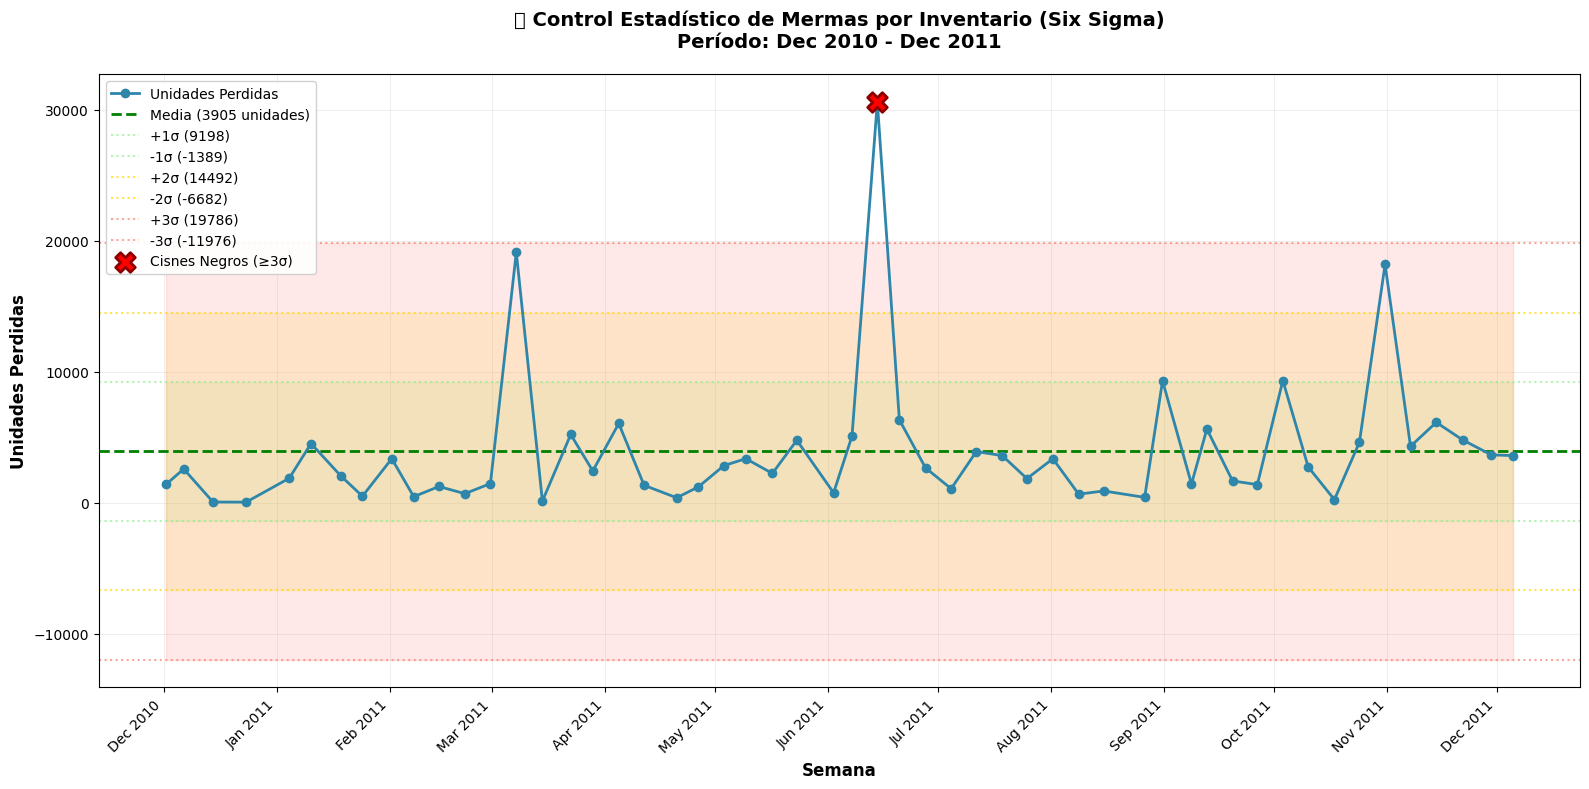


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 ESTADÍSTICAS DEL GRÁFICO DE CONTROL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Total de semanas analizadas: 53
Semanas fuera de control (≥3σ): 1
Porcentaje fuera de control: 1.9%

Límites de Control:
  +3σ (UCL): 19786 unidades
  Media:     3905 unidades
  -3σ (LCL): -11976 unidades

Semanas con eventos extremos:

  • 2011-W24: 30566 unidades (z-score: 5.04) - 5σ - Extremo
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [74]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Preparar datos para el gráfico
df_plot = df_weekly_losses.copy()
df_plot['week_start'] = pd.to_datetime(df_plot['week_start'])

# Calcular límites de control
mean = df_plot['mean_units'].iloc[0]
stddev = df_plot['stddev_units'].iloc[0]

# Crear figura
fig, ax = plt.subplots(figsize=(16, 8))

# Línea principal de mermas
ax.plot(df_plot['week_start'], df_plot['total_units_lost'], 
        marker='o', linewidth=2, markersize=6, color='#2E86AB', 
        label='Unidades Perdidas', zorder=5)

# Línea de media
ax.axhline(y=mean, color='green', linestyle='--', linewidth=2, 
           label=f'Media ({mean:.0f} unidades)', zorder=3)

# Límites de control (sigmas)
colors_sigma = {
    1: ('#90EE90', 'lightgreen'),  # 1σ - verde claro
    2: ('#FFD700', 'gold'),         # 2σ - amarillo
    3: ('#FF6B6B', 'salmon')        # 3σ - rojo claro
}

for sigma in [1, 2, 3]:
    upper = mean + sigma * stddev
    lower = mean - sigma * stddev
    
    ax.axhline(y=upper, color=colors_sigma[sigma][1], linestyle=':', 
               linewidth=1.5, alpha=0.7, label=f'+{sigma}σ ({upper:.0f})', zorder=2)
    ax.axhline(y=lower, color=colors_sigma[sigma][1], linestyle=':', 
               linewidth=1.5, alpha=0.7, label=f'-{sigma}σ ({lower:.0f})', zorder=2)
    
    # Sombreado entre límites
    ax.fill_between(df_plot['week_start'], lower, upper, 
                     color=colors_sigma[sigma][0], alpha=0.15, zorder=1)

# Marcar puntos fuera de control (≥3σ)
outliers = df_plot[abs(df_plot['z_score']) >= 3]
if len(outliers) > 0:
    ax.scatter(outliers['week_start'], outliers['total_units_lost'], 
               color='red', s=200, marker='X', edgecolors='darkred', 
               linewidths=2, label='Cisnes Negros (≥3σ)', zorder=10)

# Configuración del gráfico
ax.set_xlabel('Semana', fontsize=12, fontweight='bold')
ax.set_ylabel('Unidades Perdidas', fontsize=12, fontweight='bold')
ax.set_title('📊 Control Estadístico de Mermas por Inventario (Six Sigma)\n' + 
             f'Período: {df_plot["week_start"].min().strftime("%b %Y")} - {df_plot["week_start"].max().strftime("%b %Y")}',
             fontsize=14, fontweight='bold', pad=20)

# Formato del eje X
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45, ha='right')

# Grid
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Leyenda
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)

# Ajustar layout
plt.tight_layout()

# Mostrar
plt.show()

# Estadísticas del gráfico
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 ESTADÍSTICAS DEL GRÁFICO DE CONTROL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Total de semanas analizadas: {len(df_plot)}
Semanas fuera de control (≥3σ): {len(outliers)}
Porcentaje fuera de control: {100*len(outliers)/len(df_plot):.1f}%

Límites de Control:
  +3σ (UCL): {mean + 3*stddev:.0f} unidades
  Media:     {mean:.0f} unidades
  -3σ (LCL): {mean - 3*stddev:.0f} unidades

Semanas con eventos extremos:
""")

if len(outliers) > 0:
    for idx, row in outliers.iterrows():
        print(f"  • {row['year_week']}: {row['total_units_lost']:.0f} unidades (z-score: {row['z_score']:.2f}) - {row['sigma_classification']}")
else:
    print("  ✅ No se detectaron eventos extremos (≥3σ)")

print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

In [79]:
conn.close()

In [76]:
import duckdb

conn = duckdb.connect('D:/github_projects/bi-supermarket-data/dwh/retail_analytics.duckdb')

# Ver tablas
conn.execute("SHOW TABLES FROM main_silver").df()

# Consultar
df = conn.execute("SELECT * FROM main_silver.dim_products LIMIT 10").df()
print(df)

conn.close()

  stock_code         canonical_description  times_used  num_variations  \
0      10002   INFLATABLE POLITICAL GLOBE           71               1   
1      10080      GROOVY CACTUS INFLATABLE          22               2   
2      10120                  DOGGY RUBBER          30               1   
3     10123C         HEARTS WRAPPING TAPE            3               1   
4     10124A   SPOTS ON RED BOOKCOVER TAPE           5               1   
5     10124G      ARMY CAMO BOOKCOVER TAPE           4               1   
6      10125       MINI FUNKY DESIGN TAPES          94               1   
7      10133  COLOURING PENCILS BROWN TUBE         199               2   
8      10135  COLOURING PENCILS BROWN TUBE         180               1   
9      11001   ASSTD DESIGN RACING CAR PEN         120               1   

   total_transactions          first_seen           last_seen  \
0                  73 2010-12-01 08:45:00 2011-04-28 15:05:00   
1                  24 2011-02-27 13:47:00 2011-11-21 17

In [78]:
import duckdb
import pandas as pd

# Conectar
conn = duckdb.connect('D:/github_projects/bi-supermarket-data/dwh/retail_analytics.duckdb')

# Query 1: KPIs financieros
df_kpis = conn.execute("""
    SELECT * FROM main_gold.financial_kpis ORDER BY year_month
""").df()

print(df_kpis)

# Query 2: Segmentación de clientes
df_segments = conn.execute("""
    SELECT customer_segment, COUNT(*) as num_customers
    FROM main_gold.customer_rfm 
    GROUP BY customer_segment
""").df()

print(df_segments)

# Query 3: Productos estrella
df_stars = conn.execute("""
    SELECT * FROM main_gold.product_performance 
    WHERE product_classification = 'Star Product'
    ORDER BY total_revenue DESC
""").df()

print(df_stars)

# Cerrar conexión
conn.close()

   year_month  total_gross_revenue  total_returns  total_net_revenue  \
0     2010-12            791549.69      -70392.27          721157.42   
1     2011-01            671992.41     -124868.03          547124.38   
2     2011-02            508952.87      -19209.92          489742.95   
3     2011-03            691485.70      -21813.14          669672.56   
4     2011-04            516309.79      -33316.91          482992.88   
5     2011-05            741275.74      -21831.46          719444.28   
6     2011-06            738876.88      -24086.26          714790.62   
7     2011-07            689397.74      -22290.30          667107.44   
8     2011-08            725605.16      -45418.29          680186.87   
9     2011-09           1030500.36      -31132.22          999368.14   
10    2011-10           1106686.49      -60362.97         1046323.52   
11    2011-11           1457745.53      -42567.27         1415178.26   
12    2011-12            615501.60     -204650.16          41085